In [1]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy.stats

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

c:\Users\oskar\OneDrive\UNI\AP1\GitHub\AP1-Gruppe-143\Tools.py:240: SyntaxWarning: invalid escape sequence '\h'
  print(f"Da $z = \\left|\\frac{{\hat x-y}}{{\Delta x}}\\right| = \\left|\\frac{{ {Bestwert:.2f} {Einheit} - {Literaturwert:.2f} {Einheit}}}{{{Standardunsicherheit:.2f} {Einheit} }} \\right| = {z:.2f} > 2$, weicht unser Ergebnis Signifikant vom Literaturwert ab.")
c:\Users\oskar\OneDrive\UNI\AP1\GitHub\AP1-Gruppe-143\Tools.py:240: SyntaxWarning: invalid escape sequence '\D'
  print(f"Da $z = \\left|\\frac{{\hat x-y}}{{\Delta x}}\\right| = \\left|\\frac{{ {Bestwert:.2f} {Einheit} - {Literaturwert:.2f} {Einheit}}}{{{Standardunsicherheit:.2f} {Einheit} }} \\right| = {z:.2f} > 2$, weicht unser Ergebnis Signifikant vom Literaturwert ab.")
c:\Users\oskar\OneDrive\UNI\AP1\GitHub\AP1-Gruppe-143\Tools.py:241: SyntaxWarning: invalid escape sequence '\h'
  else: print(f"Da $z = \\left|\\frac{{\hat x-y}}{{\Delta x}}\\right| = \\left|\\frac{{ {Bestwert:.2f} {Einheit} - {Literaturwert:.2f}

<Axes: xlabel='Länge (m)', ylabel='Wiederstand ($\\Omega$)'>

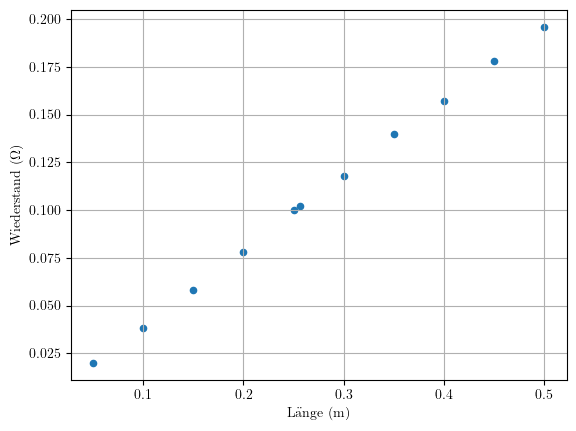

In [2]:
r = 0.25e-3/2 # Radius in m
A = np.pi * r**2 # Querschnittsfläche in m^2

# Laden und Ordnen der Daten
messdaten = pd.read_excel("V44.xlsx", sheet_name="Teil 2")
messdaten = messdaten.drop(columns=["Schaltung 3", "Mesung", "Bereich", "Wiederstand", "spez R"])  # Entferne die Spalten
messdaten.sort_values(by="Länge (m)", inplace=True)  # Sortiere die Daten nach Länge

# Fügt die Spalten für Widerstand und spezifischen Widerstand hinzu
messdaten[r"Wiederstand ($\Omega$)"] = messdaten["U(V)"] / messdaten["I(A)"]  # Berechne den Widerstand
messdaten[r"spez R"] = messdaten[r"Wiederstand ($\Omega$)"] * (A / messdaten["Länge (m)"])  # Berechne den spezifischen Widerstand

messdaten.plot(x=r"Länge (m)", y=r"Wiederstand ($\Omega$)", kind="scatter", legend=True, grid=True)
# print(messdaten)

In [3]:
l = messdaten[r"Länge (m)"].to_numpy()
R = messdaten[r"Wiederstand ($\Omega$)"].to_numpy()

error = np.array([0.001]*len(l))  # Fehler in Ohm

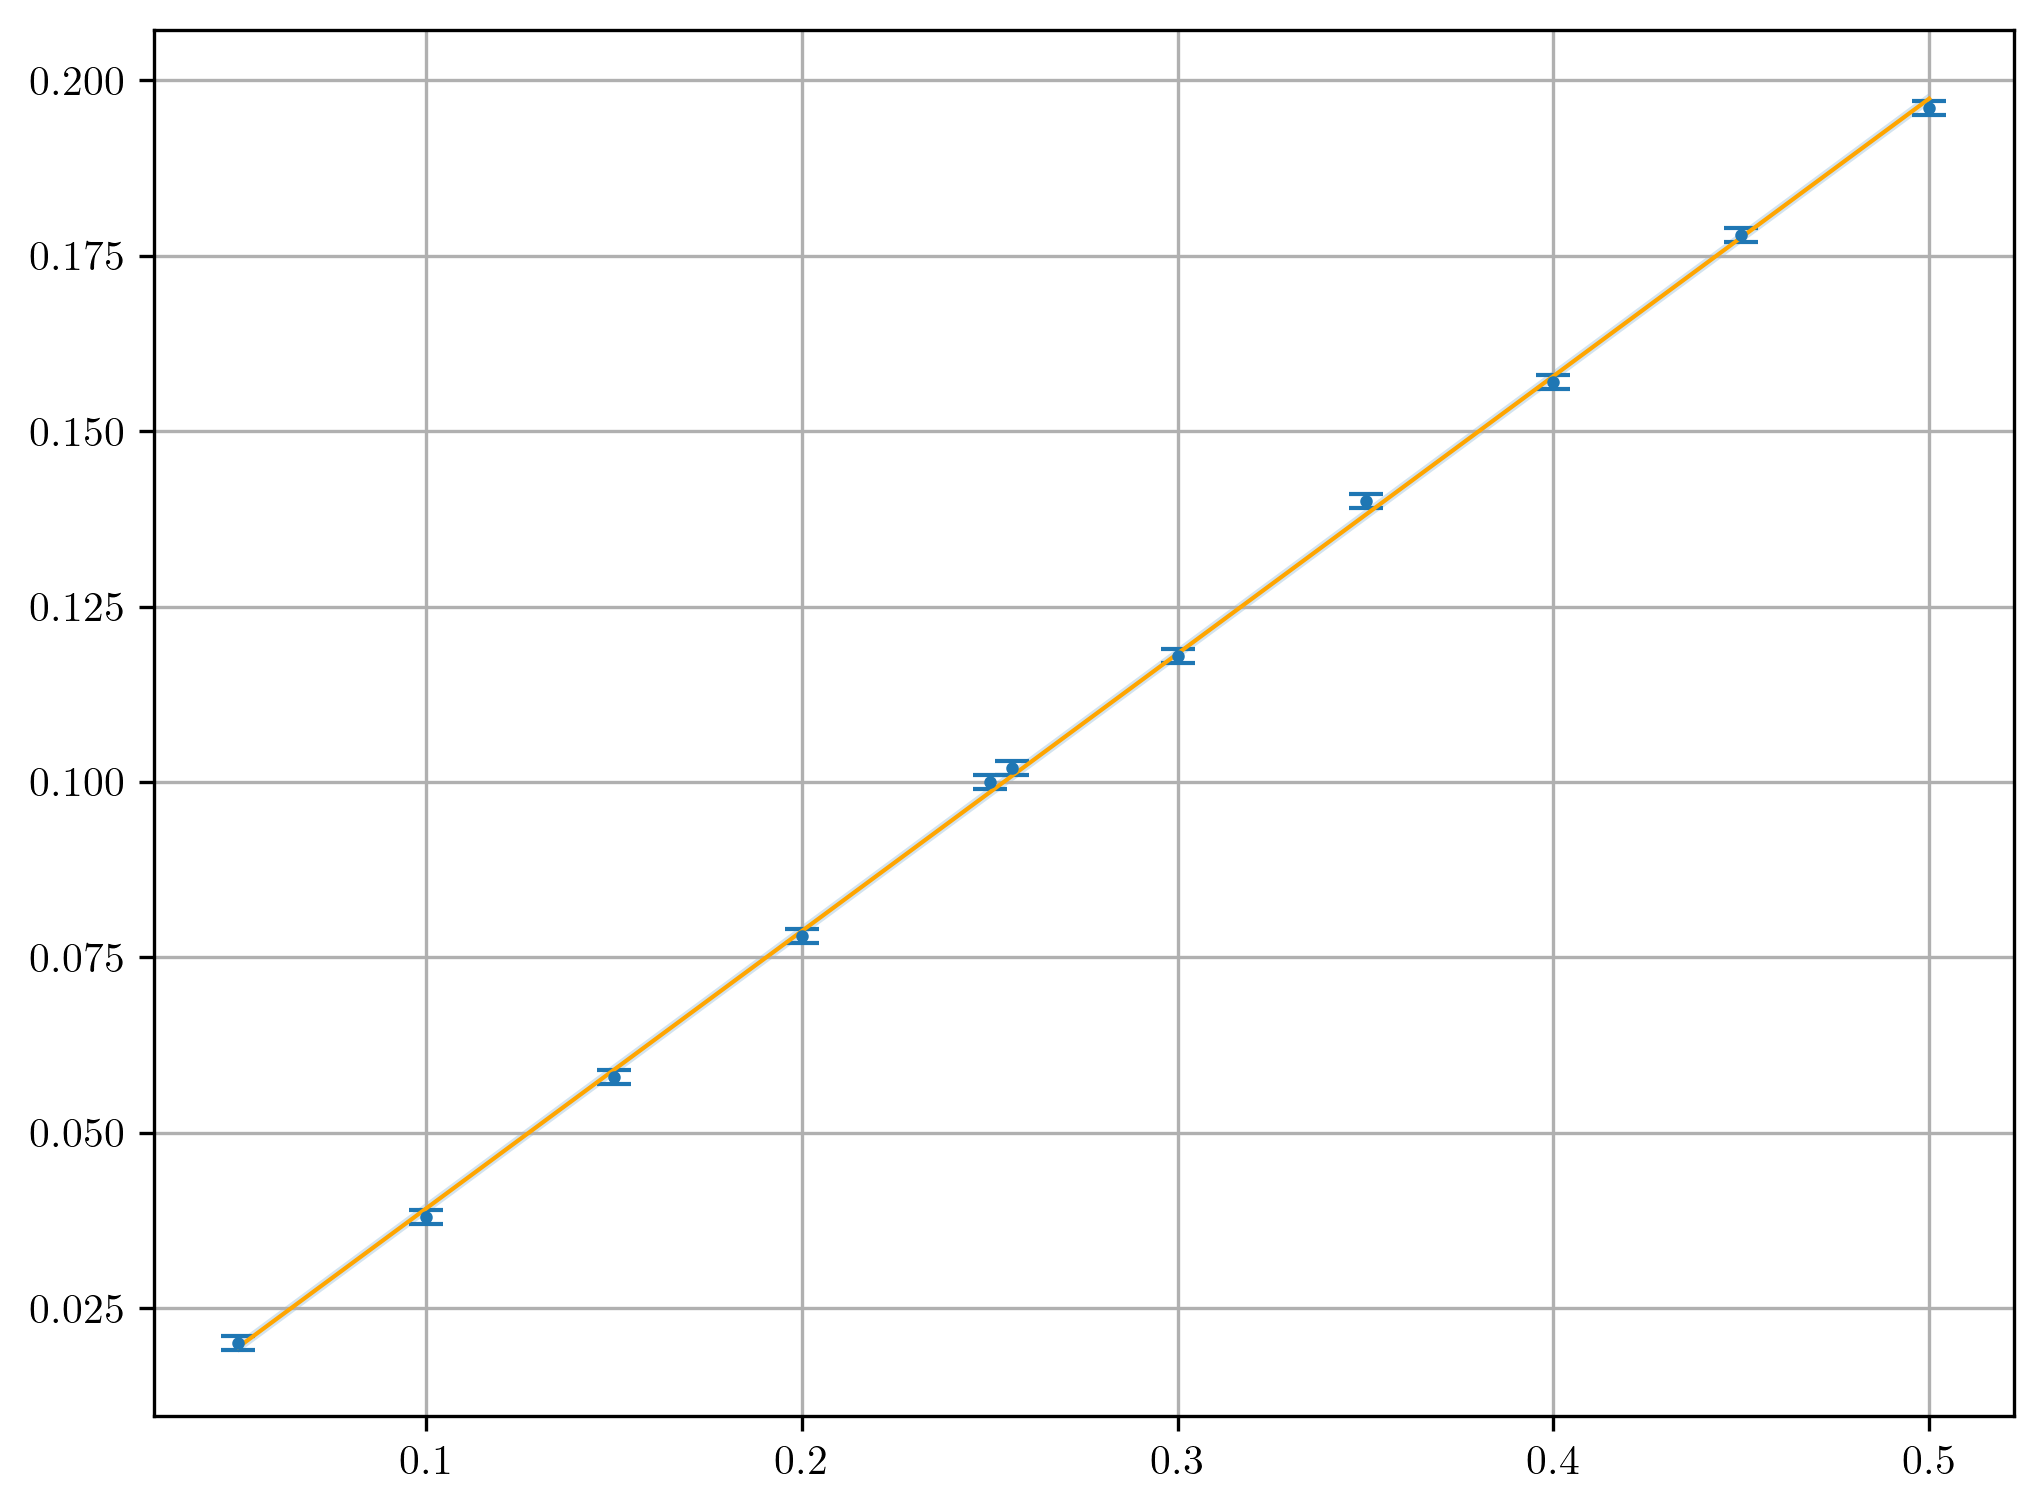

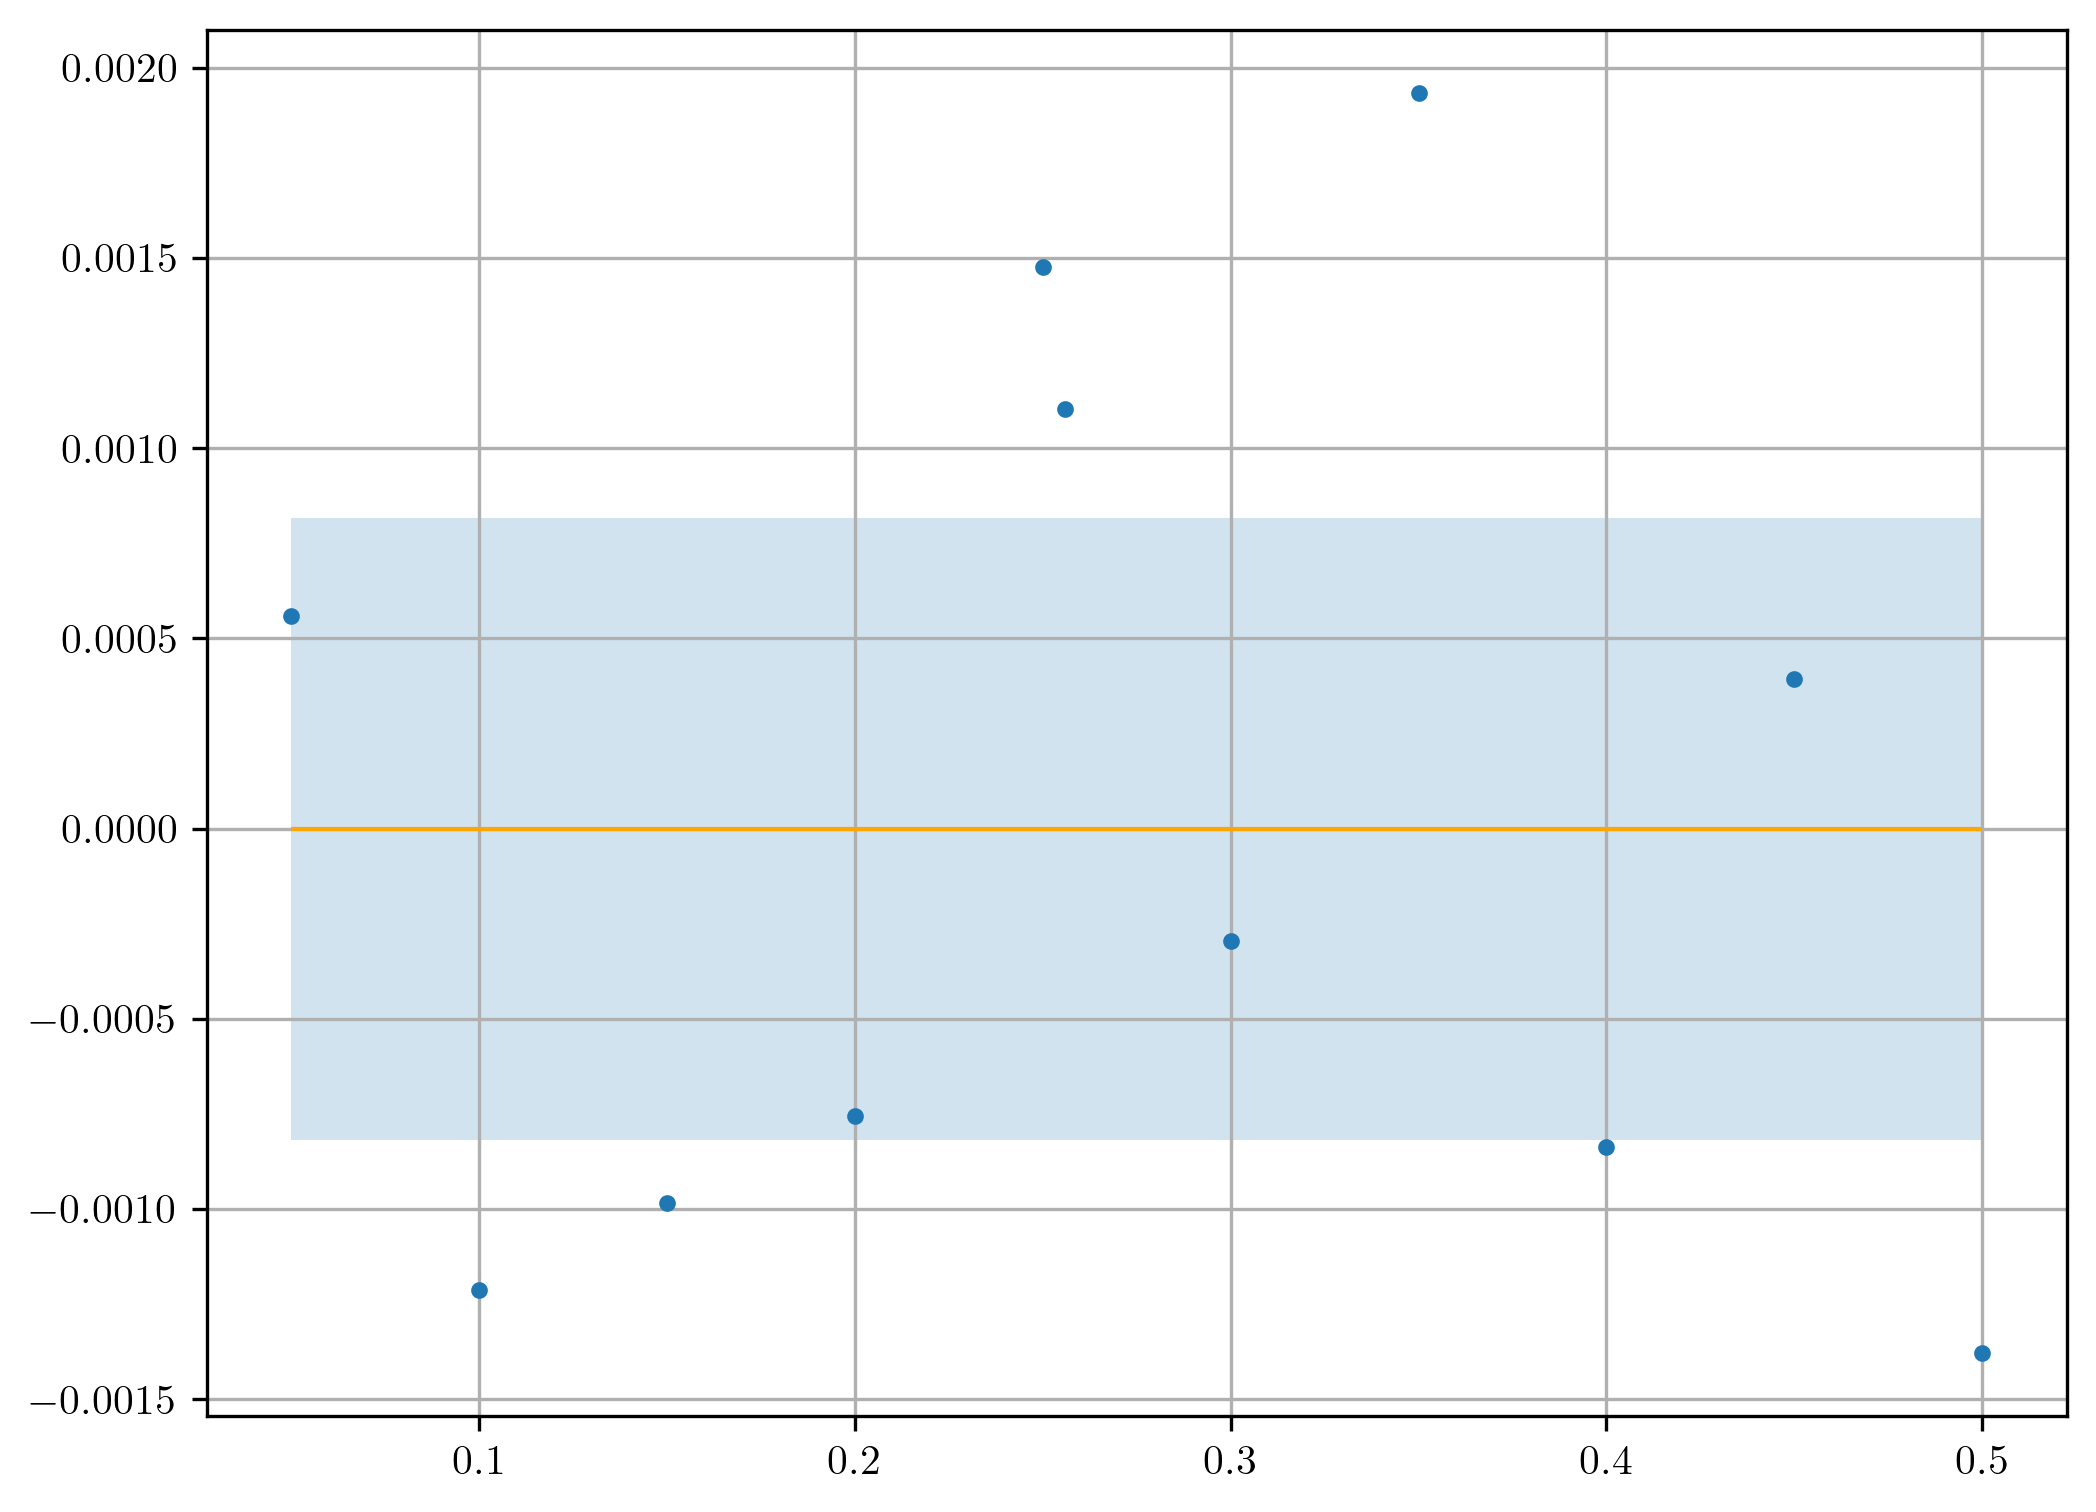

end=> Steigung: 0.3954 ± 0.0027, Achsenabschnitt: -0.0003 ± 0.0008


In [4]:
# simpy test 
linfit = scipy.stats.linregress(l, R)

# fig, ax = plt.subplots(dpi=300)
# ax.plot(l, R, '.', label='Messdaten')
# ax.plot(l, linfit.slope * l + linfit.intercept, '-', label='Lineare Regression')
# ax.set_xlabel('Länge (m)')
# ax.set_ylabel('Widerstand ($\Omega$)')
# ax.grid()
# plt.show()


Residuendiagramm_manuell(l, R, error, linfit.slope, linfit.intercept, linfit.stderr, linfit.intercept_stderr)
print(f"end=> Steigung: {linfit.slope:.4f} ± {linfit.stderr:.4f}, Achsenabschnitt: {linfit.intercept:.4f} ± {linfit.intercept_stderr:.4f}")


In [ ]:
# Werte Berechnen

print("Spezifischer Widerstand: ", np.mean(messdaten[r"spez R"]))

Spezifischer Widerstand:  1.9315855091545123e-08
